In [1]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' # default is true, 90% of GPU VRAM preallocated

In [2]:
DATA_DIR = Path.cwd().parent.parent / "data" / "helmholtz_data" 
FILE_PATH = DATA_DIR / "Helmholtz_Analytical_Meta.h5"

In [3]:
import h5py

all_a = []
all_u = []
all_bc = []

with h5py.File(FILE_PATH, 'r') as f:
    num_samples = len(f.keys())
    for i in range(num_samples):
        sample_key = f"Sample_{i}"
        all_a.append(jnp.array(f[sample_key]['a'][:]).reshape(-1, 1))
        all_u.append(jnp.array(f[sample_key]['u'][:]).reshape(-1, 1))
        all_bc.append(f[sample_key]['bc'][()])

# Stack into JAX arrays. Shape becomes (num_samples, total_points, 1)
a_meta = jnp.stack(all_a)
u_meta = jnp.stack(all_u)
bc_meta = jnp.array(all_bc)

print(f"Loaded {num_samples} meta samples.")
print(f"Meta Spatial Field 'a' Shape: {a_meta.shape}")

E0703 13:11:43.080699  426513 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0703 13:11:43.092977  426281 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


Loaded 3 meta samples.
Meta Spatial Field 'a' Shape: (3, 4096, 1)


In [4]:
nx, ny = 64, 64

x_coords = np.linspace(-1.0, 1.0, nx, dtype=np.float64)
y_coords = np.linspace(-1.0, 1.0, ny, dtype=np.float64)
X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

x_l, x_u = -1.0, 1.0
y_l, y_u = -1.0, 1.0

bc_left = (x == x_l).flatten() 
bc_right = (x == x_u).flatten()
bc_bottom = (y == y_l).flatten()
bc_top = (y == y_u).flatten()

bc_all = bc_left | bc_right | bc_bottom | bc_top 

# Extract only boundary coordinates
x_bc = x[bc_all]
y_bc = y[bc_all]
# (Deleted the bc_val_array line from here)

In [5]:
epochs = 10
M = 512 
chunk_size = 256 
hidden_layers = [256, 256, 256, 256] 
total_features = (2 * M) + sum(hidden_layers) # 1024

sigma = 1.0 
tik_reg_fixed = 1e-4 
pde_weight = 1
bc_weight = 1e3
data_weight = 1

rff_key = jax.random.PRNGKey(99)
B_matrix_base = jax.random.normal(rff_key, (2, M))

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix_base: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):  
        # Define trainable parameters for sigma and tik_reg
        raw_sigma = self.param('raw_sigma', nn.initializers.constant(1.0), (1,))
        raw_tik = self.param('raw_tik', nn.initializers.constant(-4.0), (1,))
        
        # Enforce positive sigma using softplus
        sigma = jax.nn.softplus(raw_sigma)
          
        v = jnp.concatenate([x_in, y_in])
        # Dynamically scale the B_matrix by the trainable sigma parameter
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix_base * sigma)
        
        h_rff = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])
        all_features = [h_rff]

        h = h_rff
        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = jnp.sin(h) 
            all_features.append(h)
            
        combined_h = jnp.concatenate(all_features)
        return combined_h
    
# Pass the unscaled B_matrix_base to the model
model = FeatureExtractor(hidden_layers=hidden_layers, B_matrix_base=B_matrix_base)

key = jax.random.PRNGKey(0)
params = model.init(key, jnp.array([0.0]), jnp.array([0.0]))

In [6]:
def get_f(params, x_val, y_val):
    return model.apply(params, x_val, y_val)

def get_f_dir(params, x_val, y_val):
    f_xx = jacfwd(jacfwd(get_f, argnums=1), argnums=1)(params, x_val, y_val)
    f_yy = jacfwd(jacfwd(get_f, argnums=2), argnums=2)(params, x_val, y_val)
    
    f_xx = jnp.squeeze(f_xx, axis=(-1, -2))
    f_yy = jnp.squeeze(f_yy, axis=(-1, -2))
    return f_xx, f_yy

def get_f_chunk(params, x_val, y_val, start_idx, end_idx):
    f = model.apply(params, x_val, y_val)
    return lax.dynamic_slice(f, (start_idx,), (end_idx - start_idx,))

def get_f_dir_chunk(params, x_val, y_val, start_idx, end_idx):
    f_xx_chunk = jacfwd(jacfwd(get_f_chunk, argnums=1), argnums=1)(params, x_val, y_val, start_idx, end_idx)
    f_yy_chunk = jacfwd(jacfwd(get_f_chunk, argnums=2), argnums=2)(params, x_val, y_val, start_idx, end_idx)
    
    f_xx_chunk = jnp.squeeze(f_xx_chunk, axis=(-1, -2))
    f_yy_chunk = jnp.squeeze(f_yy_chunk, axis=(-1, -2))
    return f_xx_chunk, f_yy_chunk

def get_u_dir(params, x_val, y_val, w_current):
    f_xx, f_yy = get_f_dir(params, x_val, y_val)
    u_xx = jnp.dot(f_xx, w_current)
    u_yy = jnp.dot(f_yy, w_current)
    return u_xx, u_yy

# VMAPs reverted
f_spatial_vmap = vmap(get_f, in_axes=(None, 0, 0))
f_dir_spatial_vmap = vmap(get_f_dir, in_axes=(None, 0, 0))
f_chunk_spatial_vmap = vmap(get_f_chunk, in_axes=(None, 0, 0, None, None))
f_dir_chunk_spatial_vmap = vmap(get_f_dir_chunk, in_axes=(None, 0, 0, None, None))
u_dir_spatial_vmap = vmap(get_u_dir, in_axes=(None, 0, 0, None))

In [7]:
optimizer = optax.adamw(learning_rate=1e-4, weight_decay=1e-4)

def get_A_and_b(params, x_pde, y_pde, a_pde, x_bc, y_bc, bc_val_arr, total_features, chunk_size):
    A_chunks = []
    for start_idx in range(0, total_features, chunk_size):
        end_idx = min(start_idx + chunk_size, total_features)
        f_xx, f_yy = f_dir_chunk_spatial_vmap(params, x_pde, y_pde, start_idx, end_idx)
        f_chunk = f_chunk_spatial_vmap(params, x_pde, y_pde, start_idx, end_idx)
        
        # Physics equation: Delta u + u = h
        A_pde_chunk = f_xx + f_yy + f_chunk
        A_bc_chunk = f_chunk_spatial_vmap(params, x_bc, y_bc, start_idx, end_idx) * jnp.sqrt(bc_weight)
        
        A_chunk = jnp.vstack([A_pde_chunk, A_bc_chunk])
        A_chunks.append(A_chunk)
        
    A_full = jnp.hstack(A_chunks)
    
    # a_pde contains our source term 'h'
    b_pde = a_pde
    b_bc = bc_val_arr * jnp.sqrt(bc_weight)
    b_full = jnp.vstack([b_pde, b_bc])
    return A_full, b_full

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def solve_w(params, x_pde, y_pde, a_pde, x_bc, y_bc, bc_val_arr, total_features, chunk_size):
    A, b = get_A_and_b(params, x_pde, y_pde, a_pde, x_bc, y_bc, bc_val_arr, total_features, chunk_size)
    raw_tik = params['params']['raw_tik'][0]
    tik_reg = 10.0 ** raw_tik
    AtA = A.T @ A + tik_reg * jnp.eye(total_features)
    Atb = A.T @ b
    return jnp.linalg.solve(AtA, Atb)

def compute_loss(params, w_current, x_batch, y_batch, a_batch, x_bc, y_bc, bc_val_arr, u_batch):
    u_xx, u_yy = u_dir_spatial_vmap(params, x_batch, y_batch, w_current)
    laplacian_u = u_xx + u_yy
    f_interior = f_spatial_vmap(params, x_batch, y_batch)
    u_pred_interior = jnp.dot(f_interior, w_current)
    
    # Residual: (Delta u + u) - h
    pde_residual = (laplacian_u + u_pred_interior) - a_batch
    f_bc_vals = f_spatial_vmap(params, x_bc, y_bc)
    u_bc_pred = jnp.dot(f_bc_vals, w_current)
    
    loss_pde = jnp.mean(pde_residual ** 2) * pde_weight
    loss_bc = jnp.mean((u_bc_pred - bc_val_arr) ** 2) * bc_weight
    
    # PURE PHYSICS: We calculate data loss just to print it, but DO NOT add it to total_loss
    loss_data = jnp.mean((u_pred_interior - u_batch) ** 2) 
    total_loss = loss_pde + loss_bc 
    
    return total_loss, (loss_pde, loss_bc, loss_data)

def full_step(params, x_batch, y_batch, a_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size):
    w_current = solve_w(params, x_batch, y_batch, a_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size)
    (loss, (loss_pde, loss_bc, loss_data)) = compute_loss(params, w_current, x_batch, y_batch, a_batch, x_bc, y_bc, bc_val_arr, u_batch)
    
    raw_tik = params['params']['raw_tik'][0]
    tik_reg = 10.0 ** raw_tik
    sigma = jax.nn.softplus(params['params']['raw_sigma'][0])
    return loss, (loss_pde, loss_bc, loss_data, sigma, tik_reg)

loss_grad_fn = jax.jit(
    value_and_grad(full_step, argnums=0, has_aux=True), 
    static_argnames=['total_features', 'chunk_size']
)

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def update_network(params, opt_state, x_batch, y_batch, a_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size):
    (loss, aux_losses), grads = loss_grad_fn(
        params, x_batch, y_batch, a_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size
    )
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss, aux_losses

In [8]:
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

total_points = x.shape[0] # This is 4096 for a 64x64 grid
spatial_batch_size = 2048 # Sample half the grid per step
loss_history = []
epochs = 500

for epoch in tqdm(range(epochs), desc="Meta-Learning (Pure Physics)"):
    rng, step_key, sample_key = jax.random.split(rng, 3)
    
    # 1. Randomly select WHICH PDE problem to solve this step
    sample_idx = jax.random.choice(sample_key, num_samples)
    a_flat_current = a_meta[sample_idx]
    u_flat_current = u_meta[sample_idx]
    bc_current_val = bc_meta[sample_idx]
    
    # 2. Setup the specific boundary conditions for this sample
    bc_val_array = jnp.ones_like(x_bc) * bc_current_val
    
    # 3. Randomly select WHERE in the grid to sample points
    batch_idx = jax.random.choice(step_key, total_points, shape=(spatial_batch_size,), replace=False)
    
    x_chunk = x[batch_idx]
    y_chunk = y[batch_idx]
    a_chunk = a_flat_current[batch_idx]
    u_chunk = u_flat_current[batch_idx]
    
    # 4. Update Network
    params, opt_state, loss, (l_pde, l_bc, l_data, curr_sigma, curr_tik) = update_network(
        params, opt_state, x_chunk, y_chunk, a_chunk, x_bc, y_bc, bc_val_array, u_chunk, total_features, chunk_size
    )
    loss_history.append(loss)
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch} | PDE ID: {sample_idx} | Total Loss: {loss:.4e} | PDE: {l_pde:.4e} | BC: {l_bc:.4e} | Data(Untrained): {l_data:.4e}")

Meta-Learning (Pure Physics):   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 0 | PDE ID: 0 | Total Loss: 1.8622e-10 | PDE: 1.4643e-10 | BC: 3.9786e-11 | Data(Untrained): 3.0302e-14
Epoch 50 | PDE ID: 0 | Total Loss: 1.8968e-10 | PDE: 1.4446e-10 | BC: 4.5211e-11 | Data(Untrained): 1.7565e-14
Epoch 100 | PDE ID: 0 | Total Loss: 1.9056e-10 | PDE: 1.3017e-10 | BC: 6.0392e-11 | Data(Untrained): 3.2281e-14
Epoch 150 | PDE ID: 2 | Total Loss: 3.6423e-04 | PDE: 2.6916e-04 | BC: 9.5068e-05 | Data(Untrained): 2.5926e-07
Epoch 200 | PDE ID: 1 | Total Loss: 5.8086e-10 | PDE: 2.5686e-10 | BC: 3.2400e-10 | Data(Untrained): 5.3176e-14
Epoch 250 | PDE ID: 0 | Total Loss: 1.7898e-10 | PDE: 1.2986e-10 | BC: 4.9113e-11 | Data(Untrained): 1.5765e-14
Epoch 300 | PDE ID: 2 | Total Loss: 1.3890e-04 | PDE: 1.1279e-04 | BC: 2.6118e-05 | Data(Untrained): 3.6563e-08
Epoch 350 | PDE ID: 0 | Total Loss: 1.8615e-10 | PDE: 1.3585e-10 | BC: 5.0300e-11 | Data(Untrained): 2.7749e-14
Epoch 400 | PDE ID: 0 | Total Loss: 1.9626e-10 | PDE: 1.2116e-10 | BC: 7.5102e-11 | Data(Untrained): 2.3512

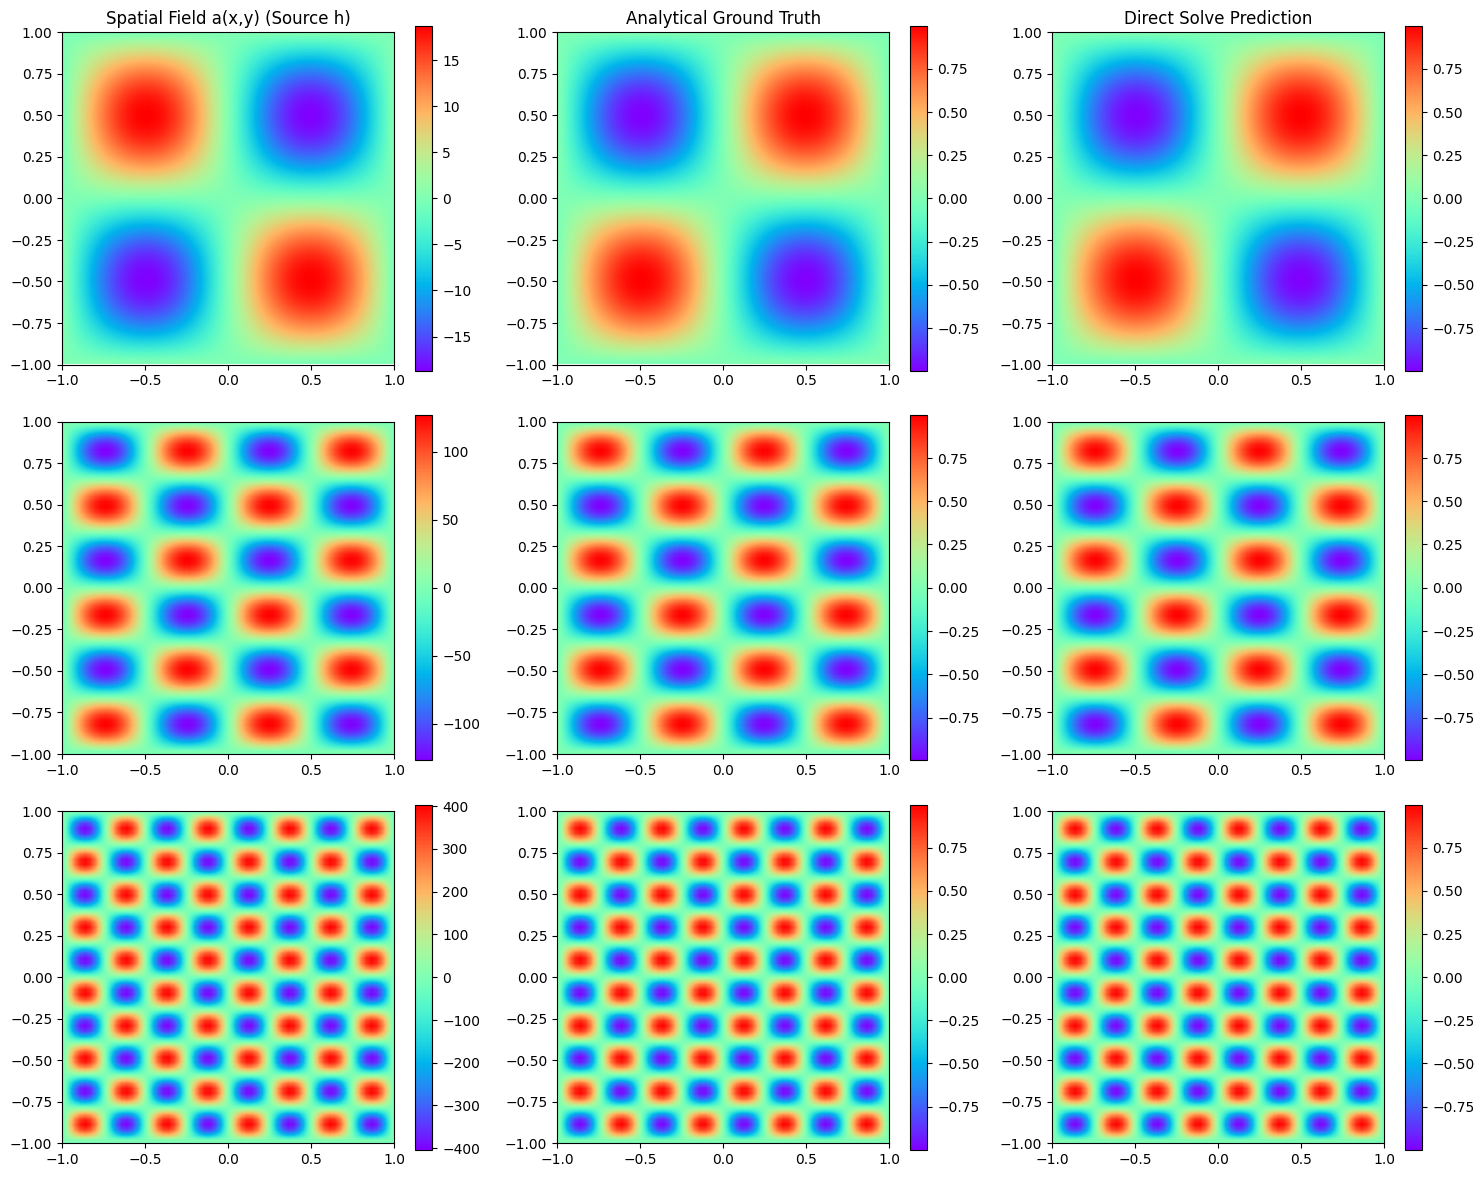

In [9]:
fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4 * num_samples))
ext = [-1, 1, -1, 1]

# Reusable MLP features (calculated once for the whole grid)
f_full = f_spatial_vmap(params, x, y)

for idx in range(num_samples):
    a_flat_current = a_meta[idx]
    u_flat_current = u_meta[idx]
    bc_val_array = jnp.ones_like(x_bc) * bc_meta[idx]
    
    # The direct solver calculates the perfect weights w for THIS specific sample
    w_final = solve_w(params, x, y, a_flat_current, x_bc, y_bc, bc_val_array, total_features, chunk_size)
    
    # Multiply the generalized features by the specific weights
    u_pred_full = jnp.dot(f_full, w_final)
    
    # Plotting
    a_plot = a_flat_current.reshape(nx, ny).T
    u_sim_plot = u_flat_current.reshape(nx, ny).T 
    u_pred_plot = u_pred_full.reshape(nx, ny).T
    
    mesh1 = axes[idx, 0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
    fig.colorbar(mesh1, ax=axes[idx, 0])
    if idx == 0: axes[idx, 0].set_title(f'Spatial Field a(x,y) (Source h)')
    
    mesh2 = axes[idx, 1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
    fig.colorbar(mesh2, ax=axes[idx, 1])
    if idx == 0: axes[idx, 1].set_title('Analytical Ground Truth')
    
    mesh3 = axes[idx, 2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
    fig.colorbar(mesh3, ax=axes[idx, 2])
    if idx == 0: axes[idx, 2].set_title('Direct Solve Prediction')

plt.tight_layout()
plt.show()